In [6]:
# Martin Konečnik, https://git.siwim.si/machine-learning/fix-qa-binary-classification
# Notebook intended for cestel specific metrics

import tomllib
from pathlib import Path

from swm import factory

In [7]:
# Read the configuration file.
with open('conf.toml', 'rb') as f:
    conf = tomllib.load(f)

EVENTS_PATH = Path().home() / conf['data_dir'] / 'prepared'
FIRST_CHANNEL = conf['first_channel']
LAST_CHANNEL = conf['last_channel']
LOAD_EVENTS = conf.get('load_events', False)
EPOCHS = conf['epoch']
LR = conf['lr']
BATCH = conf['batch']
SEEDS = conf['seeds']

In [11]:
# Read the event files.
signals_unaltered = [[] for _ in range(FIRST_CHANNEL, LAST_CHANNEL + 1)]  # Initializes an empty list for each channel.
signals_corrected = [[] for _ in range(FIRST_CHANNEL, LAST_CHANNEL + 1)]
binary_labels = []

unaltered_flags = []
unaltered_rcs = []

for event in (EVENTS_PATH / 'unaltered' / '0').iterdir():
    data = factory.read_file(event)
    for ch in range(FIRST_CHANNEL, LAST_CHANNEL + 1):
        signals_unaltered[ch].append(data.acqdata.a[ch].data)
    unaltered_flags.append(data.weighed_vehicles[0].flags)
    unaltered_rcs.append(data.weighed_vehicles[0].axle[0].rcs)

corrected_flags = []
corrected_rcs = []

for event in (EVENTS_PATH / 'corrected' / '0').iterdir():
    data = factory.read_file(event)
    for ch in range(FIRST_CHANNEL, LAST_CHANNEL + 1):
        signals_corrected[ch].append(data.acqdata.a[ch].data)
    corrected_flags.append(data.weighed_vehicles[0].flags)
    corrected_rcs.append(data.weighed_vehicles[0].axle[0].rcs)

In [12]:
# Preveri flags.
flag1 = 0x00100000
flag2 = 0x00080000

count1 = sum(1 for flag in corrected_flags if flag & flag1)
count2 = sum(1 for flag in corrected_flags if flag & flag2)

print(f"Število s flagom {hex(flag1)} v corrected: {count1}")
print(f"Število s flagom {hex(flag2)} v corrected: {count2}")

count1 = sum(1 for flag in unaltered_flags if flag & flag1)
count2 = sum(1 for flag in unaltered_flags if flag & flag2)

print(f"Število s flagom {hex(flag1)} v unaltered: {count1}")
print(f"Število s flagom {hex(flag2)} v unaltered: {count2}")

Število s flagom 0x100000 v corrected: 27
Število s flagom 0x80000 v corrected: 1192
Število s flagom 0x100000 v unaltered: 0
Število s flagom 0x80000 v unaltered: 0


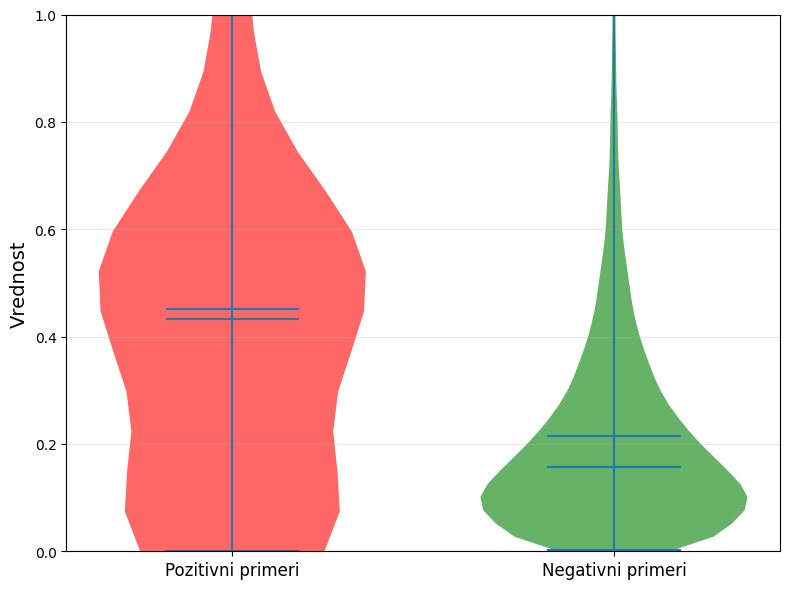

In [24]:
import matplotlib.pyplot as plt

graph_font = 14

plt.figure(figsize=(8, 6))
violin_parts = plt.violinplot([corrected_rcs, unaltered_rcs],
                              positions=[1, 2],
                              showmeans=True,
                              showmedians=True,
                              widths=0.7)

# Barvanje
violin_parts['bodies'][0].set_facecolor('red')
violin_parts['bodies'][0].set_alpha(0.6)
violin_parts['bodies'][1].set_facecolor('green')
violin_parts['bodies'][1].set_alpha(0.6)

plt.xticks([1, 2], ['Pozitivni primeri', 'Negativni primeri'], fontsize=graph_font - 2)
plt.ylabel('Vrednost', fontsize=graph_font)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()